# RideWise — Customer Segmentation

Group riders into behavioural clusters using K-Means to enable targeted retention strategies.

## Step 1 · Setup & Load

In [2]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
%matplotlib inline

PALETTE = ["#2D6A4F", "#52B788", "#E9C46A", "#E76F51"]
RED     = "#E76F51"
sns.set_theme(style="whitegrid", font_scale=1.2)

DATA_PROCESSED = os.path.join("..", "processed")
MODEL_DIR      = os.path.join("..", "models")
os.makedirs(MODEL_DIR, exist_ok=True)

features = pd.read_csv(os.path.join(DATA_PROCESSED, "features.csv"))
print(f"Features shape: {features.shape}")
features.head()


Features shape: (9204, 31)


,user_id,churned,days_since_last_trip,days_since_last_session,trips_last_7d,trips_last_30d,trips_last_60d,trips_last_90d,monetary_total,monetary_avg,...,rfm_recency_score,rfm_frequency_score,rfm_monetary_score,rfm_combined_score,account_age_days,was_referred,loyalty_status,age,city,engagement_score
0,R00000,0,25,0.0,0,1,1,3,414.13,16.57,...,2,1,4,2.33,93,1,Bronze,35,Nairobi,2.15
1,R00001,1,5,0.0,1,2,3,3,195.69,13.98,...,4,3,1,2.67,230,0,Bronze,35,Nairobi,2.90
2,R00002,1,14,0.0,0,1,4,5,482.94,20.12,...,3,1,5,3.00,232,0,Bronze,47,Lagos,2.80
3,R00004,0,12,0.0,0,2,2,5,391.15,24.45,...,3,3,3,3.00,250,1,Silver,41,Lagos,3.00
4,R00005,0,2,0.0,1,2,2,4,300.63,15.82,...,5,3,2,3.33,657,0,Bronze,40,Lagos,3.55


## Step 2 · Select Clustering Features

In [3]:
CLUSTER_COLS = [
    "rfm_recency_score", "rfm_frequency_score", "rfm_monetary_score",
    "avg_fare", "avg_surge", "tip_rate", "peak_hour_rate", "weekend_ratio",
    "session_last_30d", "avg_time_on_app", "session_conversion_rate", "engagement_score",
    "account_age_days", "activity_trend_30d",
]

seg_df = features[["user_id","churned"] + CLUSTER_COLS].dropna().copy()
print(f"Riders for segmentation: {len(seg_df):,}")


Riders for segmentation: 9,138


## Step 3 · Scale Features

In [4]:
scaler = StandardScaler()
X = scaler.fit_transform(seg_df[CLUSTER_COLS])
print(f"Scaled matrix shape: {X.shape}")


Scaled matrix shape: (9138, 14)


## Step 4 · Elbow + Silhouette Test

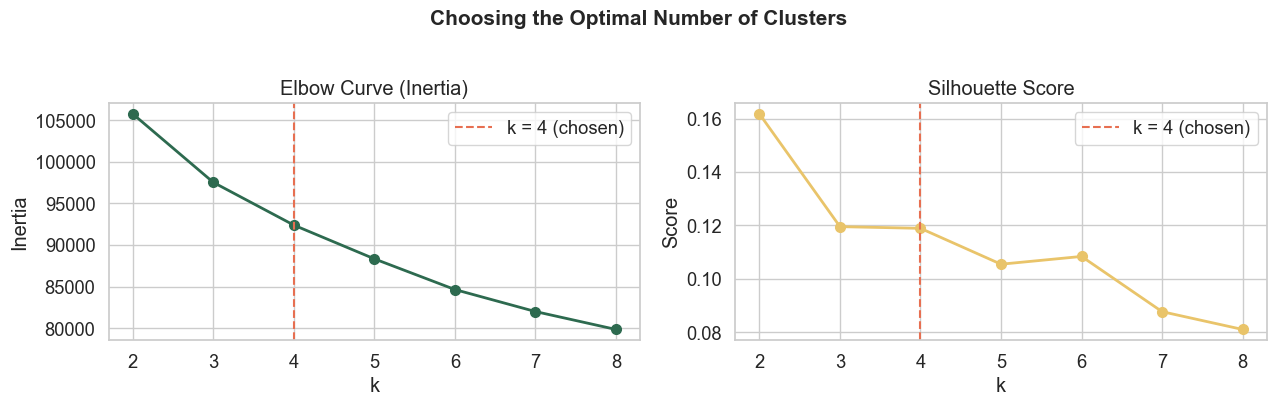

k  | Inertia     | Silhouette
----------------------------------
2  |    105,778  | 0.1618
3  |     97,541  | 0.1196
4  |     92,398  | 0.1189
5  |     88,339  | 0.1055
6  |     84,648  | 0.1084
7  |     82,000  | 0.0877
8  |     79,845  | 0.0810


In [5]:
inertias, silhouettes = [], []
K_RANGE = range(2, 9)

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels, sample_size=3000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_RANGE), inertias, "o-", color="#2D6A4F", linewidth=2, markersize=7)
axes[0].axvline(4, color=RED, linestyle="--", label="k = 4 (chosen)")
axes[0].set(title="Elbow Curve (Inertia)", xlabel="k", ylabel="Inertia")
axes[0].legend()

axes[1].plot(list(K_RANGE), silhouettes, "o-", color="#E9C46A", linewidth=2, markersize=7)
axes[1].axvline(4, color=RED, linestyle="--", label="k = 4 (chosen)")
axes[1].set(title="Silhouette Score", xlabel="k", ylabel="Score")
axes[1].legend()

plt.suptitle("Choosing the Optimal Number of Clusters", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("k  | Inertia     | Silhouette")
print("-" * 34)
for k, ine, sil in zip(K_RANGE, inertias, silhouettes):
    print(f"{k}  | {ine:>10,.0f}  | {sil:.4f}")


## Step 5 · Fit Final K-Means (k = 4)

In [6]:
K_FINAL = 4
kmeans  = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
seg_df["cluster"] = kmeans.fit_predict(X)

final_sil = silhouette_score(X, seg_df["cluster"], sample_size=3000, random_state=42)
print(f"k={K_FINAL} | Inertia: {kmeans.inertia_:,.0f} | Silhouette: {final_sil:.3f}")
print("\nCluster sizes:")
print(seg_df["cluster"].value_counts().sort_index())

joblib.dump(kmeans, os.path.join(MODEL_DIR, "kmeans_model.pkl"))
joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.pkl"))
print("\nModel and scaler saved ✓")


k=4 | Inertia: 92,398 | Silhouette: 0.119

Cluster sizes:
cluster
0    2735
1    2397
2    2904
3    1102
Name: count, dtype: int64

Model and scaler saved ✓


## Step 6 · Cluster Profiling

In [7]:
profile_cols = [
    "rfm_recency_score","rfm_frequency_score","rfm_monetary_score",
    "avg_fare","session_last_30d","engagement_score","activity_trend_30d",
    "peak_hour_rate","weekend_ratio",
]
profile = seg_df.groupby("cluster")[profile_cols].mean().round(2)
print(profile.T.to_string())


cluster                  0      1      2      3
rfm_recency_score     3.51   1.27   3.78   3.45
rfm_frequency_score   3.40   1.28   3.89   3.42
rfm_monetary_score    2.00   2.67   4.15   3.17
avg_fare             14.47  15.43  16.27  15.33
session_last_30d      4.99   5.11   5.11   4.74
engagement_score      3.09   1.62   3.91   3.37
activity_trend_30d    0.45   0.07   0.47   0.42
peak_hour_rate        0.30   0.33   0.34   0.32
weekend_ratio         0.30   0.28   0.29   0.28


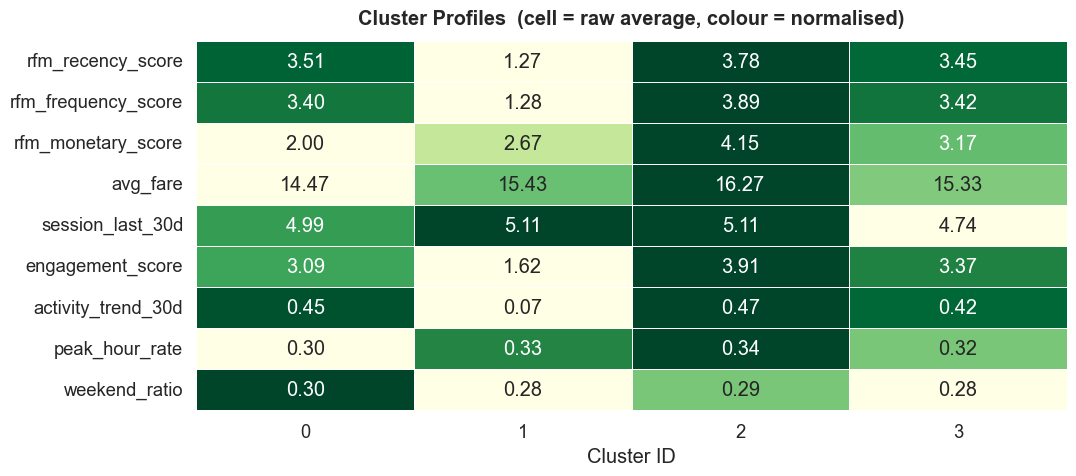

In [8]:
profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(profile_norm.T, annot=profile.T, fmt=".2f", cmap="YlGn",
            linewidths=0.5, ax=ax, cbar=False, linecolor="white")
ax.set_title("Cluster Profiles  (cell = raw average, colour = normalised)",
             fontweight="bold", pad=12)
ax.set_xlabel("Cluster ID")
plt.tight_layout()
plt.show()


## Step 7 · Assign Business Labels

In [9]:
rfm_mean = seg_df.groupby("cluster")[
    ["rfm_recency_score","rfm_frequency_score","rfm_monetary_score"]
].mean().mean(axis=1)

rank = rfm_mean.rank(ascending=False).astype(int)
SEGMENT_LABELS = {}
names = ["Champions", "Loyal Riders", "At-Risk", "Dormant"]
for cluster_id, r in rank.items():
    SEGMENT_LABELS[cluster_id] = names[r - 1]

seg_df["segment"] = seg_df["cluster"].map(SEGMENT_LABELS)
print("Segment distribution:")
print(seg_df["segment"].value_counts())
print("\nChurn rate by segment:")
print(seg_df.groupby("segment")["churned"].mean().mul(100).round(1)
      .sort_values(ascending=False).to_string())


Segment distribution:
segment
Champions       2904
At-Risk         2735
Dormant         2397
Loyal Riders    1102
Name: count, dtype: int64

Churn rate by segment:
segment
Dormant         11.7
At-Risk         10.5
Loyal Riders    10.5
Champions       10.3


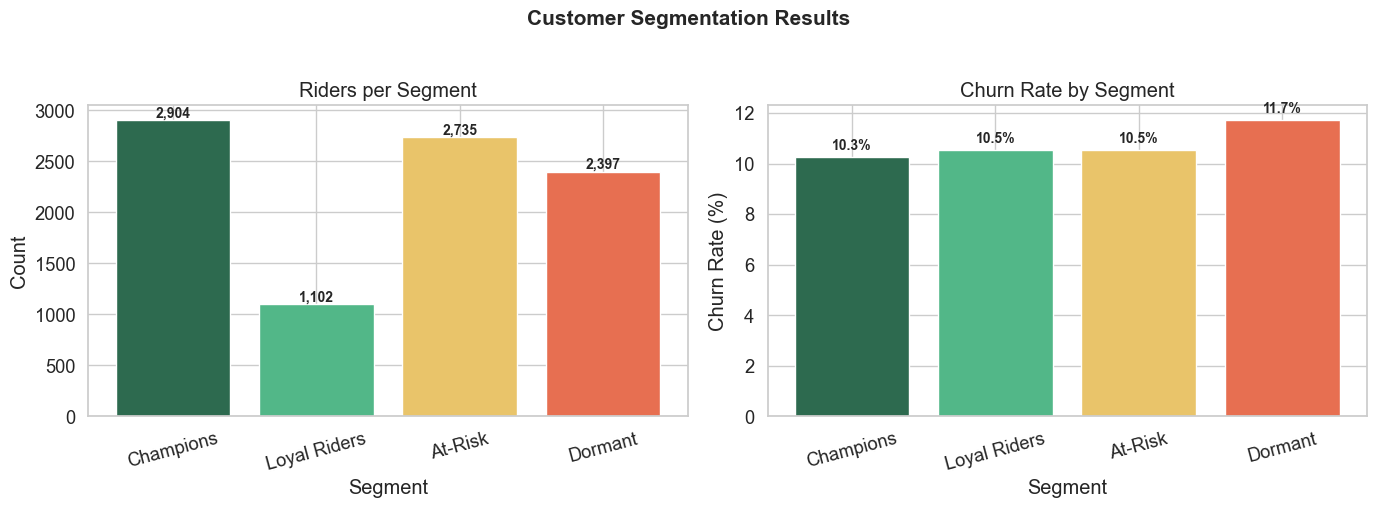

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
segment_order = ["Champions", "Loyal Riders", "At-Risk", "Dormant"]

sizes = seg_df["segment"].value_counts().reindex(segment_order)
bars  = axes[0].bar(sizes.index, sizes.values, color=PALETTE, edgecolor="white")
for bar, v in zip(bars, sizes.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 30,
                 f"{v:,}", ha="center", fontsize=10, fontweight="bold")
axes[0].set(title="Riders per Segment", xlabel="Segment", ylabel="Count")
axes[0].tick_params(axis="x", rotation=15)

churn_seg = seg_df.groupby("segment")["churned"].mean().mul(100).reindex(segment_order)
bars2 = axes[1].bar(churn_seg.index, churn_seg.values, color=PALETTE, edgecolor="white")
for bar, v in zip(bars2, churn_seg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.3,
                 f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")
axes[1].set(title="Churn Rate by Segment", xlabel="Segment", ylabel="Churn Rate (%)")
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Customer Segmentation Results", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## Step 8 · Save Segmented Data

In [11]:
out = features.merge(seg_df[["user_id","cluster","segment"]], on="user_id", how="left")
out.to_csv(os.path.join(os.path.join("..", "processed"), "features_segmented.csv"), index=False)
print(f"Saved features_segmented.csv  ({len(out):,} rows × {out.shape[1]} cols)")
print("\nSegment label map:", SEGMENT_LABELS)


Saved features_segmented.csv  (9,204 rows × 33 cols)

Segment label map: {0: 'At-Risk', 1: 'Dormant', 2: 'Champions', 3: 'Loyal Riders'}
